<a href="https://colab.research.google.com/github/RLupes0/proiect-master-econometrie/blob/main/Proiect_Master_Econometrie_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelarea Predictivă a Costurilor Medicale

Acest proiect își propune să dezvolte un model predictiv de Machine Learning capabil să estimeze cu precizie costurile medicale individuale (charges) ale asiguraților, pe baza profilului lor demografic și a stilului de viață.

Set de date - Kaggle - https://www.kaggle.com/datasets/hetmengar/medical-insurance-cost-prediction

Setul de date este utilizat pentru predictia costurilor asigurarilor medicale si contine 7 variabile (atribute), clasificate in predictori (demografici si de sanatate) si o variabila tinta:



*   age (Numeric): Varsta beneficiarului principal
*   sex (Categorial): Genul asiguratului (female / male)
*   bmi (Numeric): Indicele de masa corporala ($\text{kg/m}^2$), utilizat pentru evaluarea ponderala a corpului in raport cu inaltimea
*   children (Numeric): Numarul de copii/persoane dependente acoperite de polita de asigurare
*   smoker (Categorial): Statutul de fumator (yes / no) — identificat ca fiind un predictor cu impact major asupra costurilor
*   region (Categorial): Zona rezidentiala a beneficiarului din SUA (northeast, southeast, southwest, northwest)
*   charges (Numeric / Variabila Tinta): Costurile medicale individuale facturate de asigurare, reprezentand valoarea ce urmeaza a fi prezisa de modelele de Machine Learning








**Script import date Kaggle**

Pentru a asigura reproductibilitatea si securitatea pipeline-ului de analiza a datelor, importul setului de date a fost implementat programatic, direct din platforma Kaggle, eliminand necesitatea descarcarii si incarcarii manuale a fisierelor pe disc.

In [ ]:
import os
from google.colab import userdata

# Instalează biblioteca Kaggle
!pip install -q kaggle

try:
    # Preia credențialele din secțiunea Secrets a Colab
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USER')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("Credențialele Kaggle au fost încărcate cu succes.")
except Exception as e:
    print("Secret-urile Kaggle nu au fost găsite. Te rog adaugă 'KAGGLE_USER' și 'KAGGLE_KEY' în tab-ul Secrets (🔑).")

Credențialele Kaggle au fost încărcate cu succes.


In [ ]:
import kagglehub

# Descarcă ultima versiune a setului de date
path = kagglehub.dataset_download("hetmengar/medical-insurance-cost-prediction")

print("Calea către fișierele setului de date:", path)

Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Calea către fișierele setului de date: /kaggle/input/medical-insurance-cost-prediction


**Script import date Kaggle**

Pentru a asigura reproductibilitatea si securitatea pipeline-ului de analiza a datelor, importul setului de date a fost implementat programatic, direct din platforma Kaggle, eliminand necesitatea descarcarii si incarcarii manuale a fisierelor pe disc.

In [ ]:
import pandas as pd
import os

# Listează fișierele din directorul descărcat
files = os.listdir(path)
print(f"Fișiere în setul de date: {files}")

# Încarcă fișierul CSV (presupunând că medical-charges.csv este fișierul principal)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)

# Afișează primele rânduri
df.head()

Fișiere în setul de date: ['medical-charges.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Identificarea si Tratarea Valorilor Eronate**

Aceasta etapa de preprocesare asigura calitatea si consistenta datelor inainte de aplicarea algoritmilor de modelare, eliminand zgomotul din setul de date



*   Gestiunea Duplicatelor: Se identifica randurile identice redundante si se elimina . Acest pas previne distorsionarea rezultatelor si overfitting-ul modelelor pe informatii multiplicate artificial.
*   Tratarea Valorilor Nule: Scriptul scaneaza intreaga matrice de date pentru a depista lipsa informatiilor . In aceasta abordare, inlocuirea prin imputare a fost substituita cu eliminarea directa a randurilor incomplete, asigurand un set de date final curat si complet.
*   Alinierea Structurii si Verificarea Tipurilor: Dupa eliminarea inregistrarilor invalide, indexul dataframe-ului este reconstituit liniar pentru a evita discontinuitatile in iteratii. In final, atributul df.dtypes valideaza daca formatele variabilelor (numerice sau obiect/text) corespund naturii lor statistice, lasand setul de date optimizat pentru analiza.






In [ ]:
# 1. Verificăm și eliminăm duplicatele
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()

# 2. Verificăm și eliminăm valorile nule
null_count = df.isnull().sum().sum()
df = df.dropna()

# 3. Resetăm indexul după eliminarea rândurilor
df = df.reset_index(drop=True)

print(f"Curățare finalizată:")
print(f"- Duplicate eliminate: {duplicate_count}")
print(f"- Valori nule eliminate: {null_count}")
print(f"- Dimensiune finală set de date: {df.shape}")

# Verificăm tipurile de date pentru a ne asigura că sunt corecte pentru analiză
print("\nTipuri de date:")
print(df.dtypes)

df.head()

Curățare finalizată:
- Duplicate eliminate: 1
- Valori nule eliminate: 0
- Dimensiune finală set de date: (1337, 7)

Tipuri de date:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Analiza Descriptiva a Datelor**

Apelarea functiei df.describe() este utilizata pentru a genera sumarul statistic al variabilelor numerice din setul de date.
Aceasta analiza preliminara este esentiala pentru a intelege structura volumului de date ramas in urma curatarii, permitand identificarea asimetriilor din distributie si evaluarea gradului de variabilitate pentru predictori si pentru variabila tinta inainte de faza de modelare.

In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


**Analiza Vizuala a Variabilei Tinta**

Se observa distanta neobisnuita dintre medie si mediana pentru variabila charges.

Analizam anomalia prin creerea unui box plot si a unei histograme.

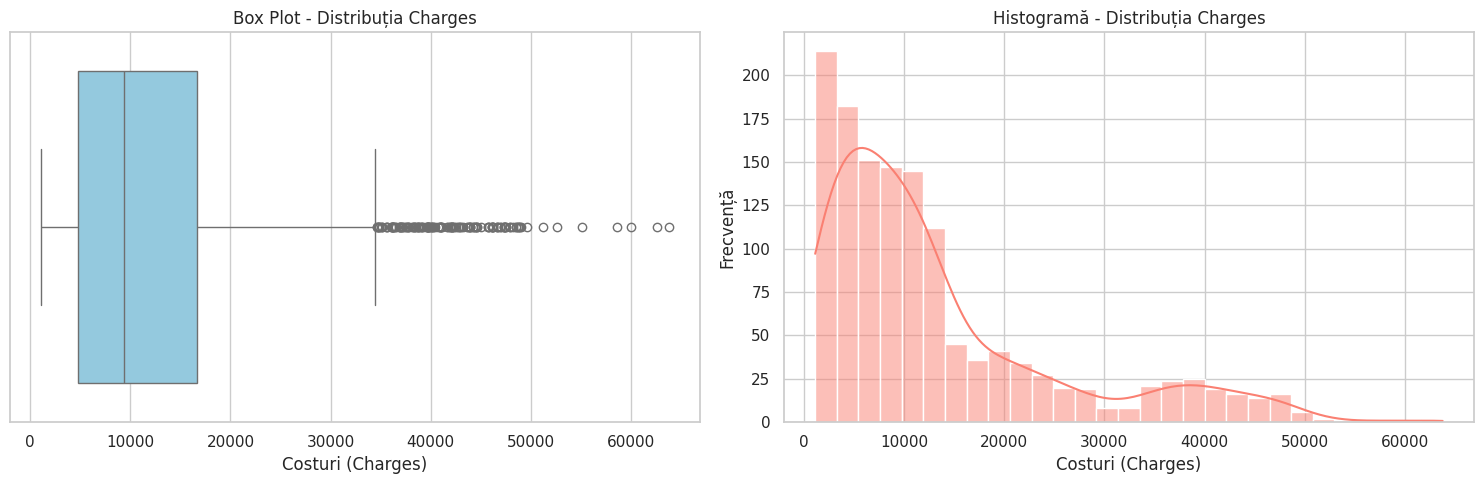

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm stilul vizualizării
sns.set(style="whitegrid")

# Creăm o figură cu două sub-grafice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Box Plot pentru charges
sns.boxplot(x=df['charges'], ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot - Distribuția Charges')
axes[0].set_xlabel('Costuri (Charges)')

# 2. Histograma pentru charges
sns.histplot(df['charges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Histogramă - Distribuția Charges')
axes[1].set_xlabel('Costuri (Charges)')
axes[1].set_ylabel('Frecvență')

plt.tight_layout()
plt.show()

Se observa o valoare mare a outlierilor si o distributie care nu este normala, fiind puternic asimetrica si inclinata spre dreapta.

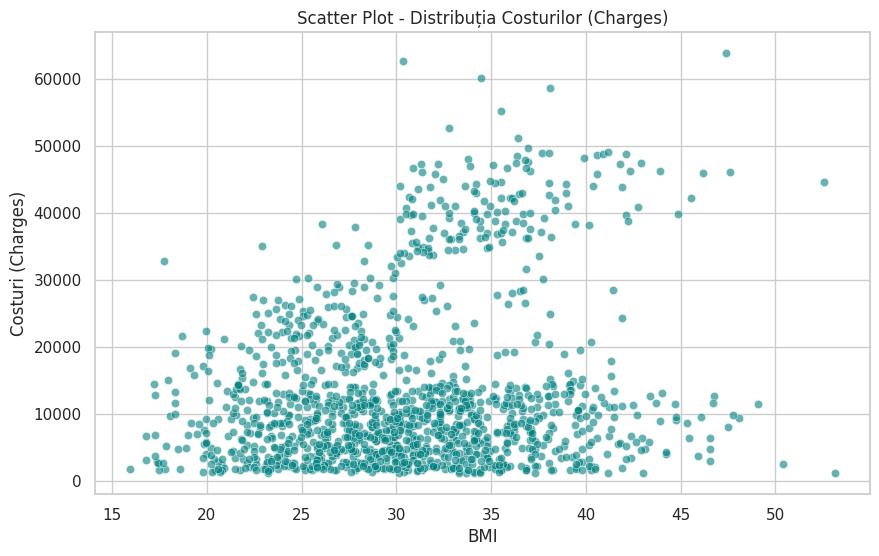

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crearea unui scatter plot pentru variabila charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bmi'], y=df['charges'], alpha=0.6, color='teal')
plt.title('Scatter Plot - Distribuția Costurilor (Charges)')
plt.xlabel('BMI')
plt.ylabel('Costuri (Charges)')
plt.show()

**Analiza Vizuala a Variabilei BMI si Comparatia cu Charges**

Prin analiza distributiei indicelui de masa corporala (bmi), se urmareste evidentierea unui profil ideal de distributie pentru a pune in contrast asimetria observata anterior la variabila charges.

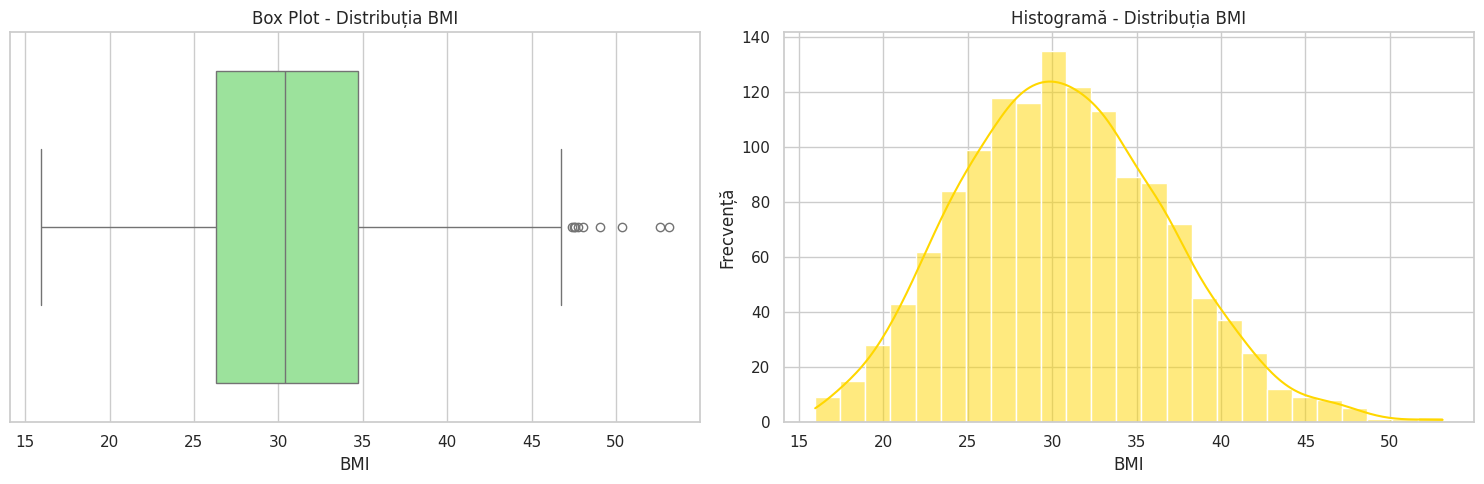

In [ ]:
# Creăm o figură cu două sub-grafice pentru variabila BMI
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Box Plot pentru BMI
sns.boxplot(x=df['bmi'], ax=axes[0], color='lightgreen')
axes[0].set_title('Box Plot - Distribuția BMI')
axes[0].set_xlabel('BMI')

# 2. Histograma pentru BMI
sns.histplot(df['bmi'], kde=True, ax=axes[1], color='gold')
axes[1].set_title('Histogramă - Distribuția BMI')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frecvență')

plt.tight_layout()
plt.show()

**Tratarea valorilor extreme din variabila charges prin logaritmare**

Pentru a corecta asimetria pronuntata a variabilei tinta si a reduce impactul negativ al outlierilor asupra viitoarelor modele de Machine Learning, s-a aplicat o transformare logaritmica.

Aceasta tehnica stabilizeaza varianta si aduce datele mai aproape de o distributie normala.

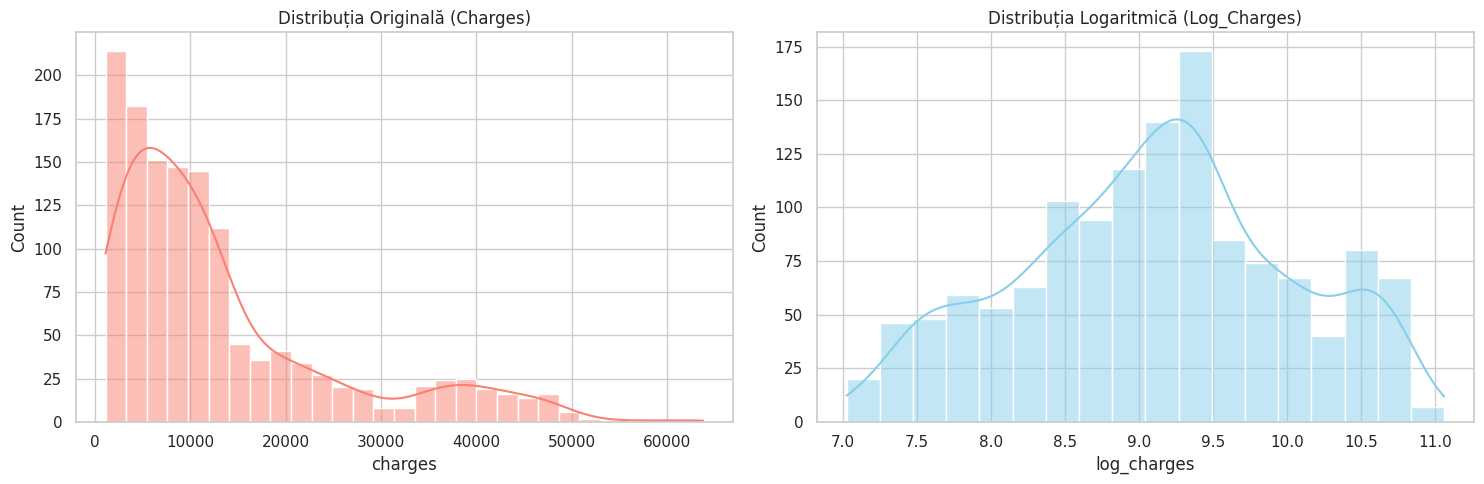

Skewness (original): 1.52
Skewness (log): -0.09


In [ ]:
import numpy as np

# Aplicăm transformarea logaritmică pentru a reduce impactul valorilor extreme
df['log_charges'] = np.log1p(df['charges'])

# Vizualizăm impactul transformării
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribuția originală
sns.histplot(df['charges'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribuția Originală (Charges)')

# 2. Distribuția după logaritmare
sns.histplot(df['log_charges'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribuția Logaritmică (Log_Charges)')

plt.tight_layout()
plt.show()

print(f"Skewness (original): {df['charges'].skew():.2f}")
print(f"Skewness (log): {df['log_charges'].skew():.2f}")

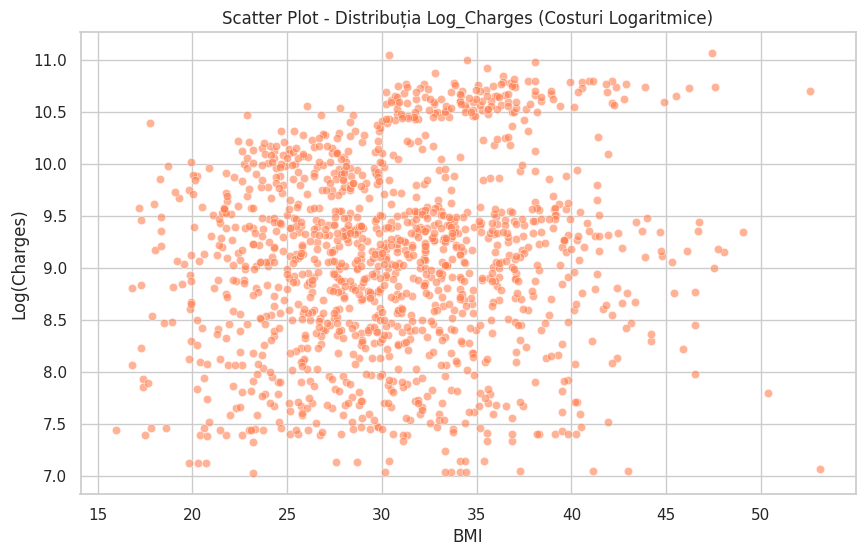

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crearea unui scatter plot pentru variabila log_charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bmi'], y=df['log_charges'], alpha=0.6, color='coral')
plt.title('Scatter Plot - Distribuția Log_Charges (Costuri Logaritmice)')
plt.xlabel('BMI')
plt.ylabel('Log(Charges)')
plt.show()

**Trasformarea varstei in categori de varsta**

Transformam variabila numerica continua age intr-o serie de variabile binare, mult mai usor de interpretat de catre anumiti algoritmi de invatare automata.

Procesul este structurat astfel:
*   Segmentarea pe Grupe de Varsta
1.   Sub 30
2.   31-46
1.   47 si peste




*   Codificarea Binara (One-Hot Encoding)
*   Consolidarea Setului de Date






In [ ]:
# 1. Definirea funcției de curățare
def elimina_duplicatele(dataframe):
    return dataframe.drop_duplicates().reset_index(drop=True)

# 2. Resetăm DataFrame-ul la coloanele originale pentru a evita duplicarea coloanelor dummy la rulări multiple
# Păstrăm doar coloanele care nu încep cu 'age_group' sau 'age_'
columns_to_keep = [c for c in df.columns if not c.startswith('age_group') and not c.startswith('age_')]
df = df[columns_to_keep].copy()

# 3. Clasificarea pe grupe de vârstă
bins = [0, 30, 46, df['age'].max()]
labels = ['Sub 30', '31-46', '47 și peste']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

# 4. Crearea variabilelor dummy (binare)
age_dummies = pd.get_dummies(df['age_group'], prefix='age').astype(int)
df = pd.concat([df, age_dummies], axis=1)

# 5. Eliminarea duplicatelor care ar fi putut apărea în proces
df = elimina_duplicatele(df)

print(f"Procesare finalizată. Dimensiune set de date: {df.shape}")
display(df[['age', 'age_group', 'age_Sub 30', 'age_31-46', 'age_47 și peste']].head())

Procesare finalizată. Dimensiune set de date: (1337, 17)


,age,age_group,age_Sub 30,age_31-46,age_47 și peste
0,19,Sub 30,1,0,0
1,18,Sub 30,1,0,0
2,28,Sub 30,1,0,0
3,33,31-46,0,1,0
4,32,31-46,0,1,0


**Codificarea Variabilelor Categoriale**

Varabila dummy sex (1 - barbat / 0 - femeie)

Mapping-ul pentru variabila sex:


,sex,sex_binary
0,female,0
1,male,1


,age,sex,bmi,children,smoker,region,charges,log_charges,age_group,age_Sub 30,age_31-46,age_47 și peste,sex_binary
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,Sub 30,1,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,Sub 30,1,0,0,1
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,Sub 30,1,0,0,1
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,31-46,0,1,0,1
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,31-46,0,1,0,1


Variabila dummmy regiune

Am creat variabile dummy pentru regiune pentru a vedea daca regiunea are un impact important aspura analizei

In [ ]:
# Crearea variabilelor dummy pentru coloana 'region'
region_dummies = pd.get_dummies(df['region'], prefix='region').astype(int)

# Adăugarea noilor coloane în DataFrame-ul principal
df = pd.concat([df, region_dummies], axis=1)

# Verificarea rezultatelor
print("Variabilele dummy pentru regiuni au fost create:")
display(df[['region', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']].head())
print(f"Dimensiune actuală set de date: {df.shape}")

Variabilele dummy pentru regiuni au fost create:


,region,region_northeast,region_northeast,region_northeast,region_northeast,region_northeast,region_northeast,region_northeast,region_northeast,region_northwest,...,region_southeast,region_southeast,region_southwest,region_southwest,region_southwest,region_southwest,region_southwest,region_southwest,region_southwest,region_southwest
0,southwest,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,1,1,1
1,southeast,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
2,southeast,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
3,northwest,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,northwest,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


Dimensiune actuală set de date: (1337, 45)


Variablia dummy smoker

In [ ]:
# Recodificarea variabilei smoker: yes = 1, no = 0
df['smoker_binary'] = df['smoker'].map({'yes': 1, 'no': 0})

# Verificăm rezultatul
print("Mapping-ul pentru variabila smoker:")
display(df[['smoker', 'smoker_binary']].drop_duplicates())

# Afișăm primele rânduri pentru confirmare
display(df.head())

Mapping-ul pentru variabila smoker:


,smoker,smoker_binary
0,yes,1
1,no,0


,age,sex,bmi,children,smoker,region,charges,log_charges,sex_binary,region_northeast,region_northwest,region_southeast,region_southwest,age_group,age_Sub 30,age_31-46,age_47 și peste,smoker_binary
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,0,0,0,0,1,Sub 30,1,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,1,0,0,1,0,Sub 30,1,0,0,0
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,1,0,0,1,0,Sub 30,1,0,0,0
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,1,0,1,0,0,31-46,0,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,1,0,1,0,0,31-46,0,1,0,0


In [ ]:
# Eliminarea coloanelor duplicate (păstrăm doar prima apariție)
df = df.loc[:, ~df.columns.duplicated()]

print(f"Coloane rămase în setul de date ({len(df.columns)}):")
print(df.columns.tolist())

display(df.head())

Coloane rămase în setul de date (18):
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'log_charges', 'sex_binary', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'age_group', 'age_Sub 30', 'age_31-46', 'age_47 și peste', 'smoker_binary']


,age,sex,bmi,children,smoker,region,charges,log_charges,sex_binary,region_northeast,region_northwest,region_southeast,region_southwest,age_group,age_Sub 30,age_31-46,age_47 și peste,smoker_binary
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236,0,0,0,0,1,Sub 30,1,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,7.453882,1,0,0,1,0,Sub 30,1,0,0,0
2,28,male,33.000,3,no,southeast,4449.46200,8.400763,1,0,0,1,0,Sub 30,1,0,0,0
3,33,male,22.705,0,no,northwest,21984.47061,9.998137,1,0,1,0,0,31-46,0,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,8.260455,1,0,1,0,0,31-46,0,1,0,0


**Analiza initiala a datelor**

Matricea de corelatie Pearson

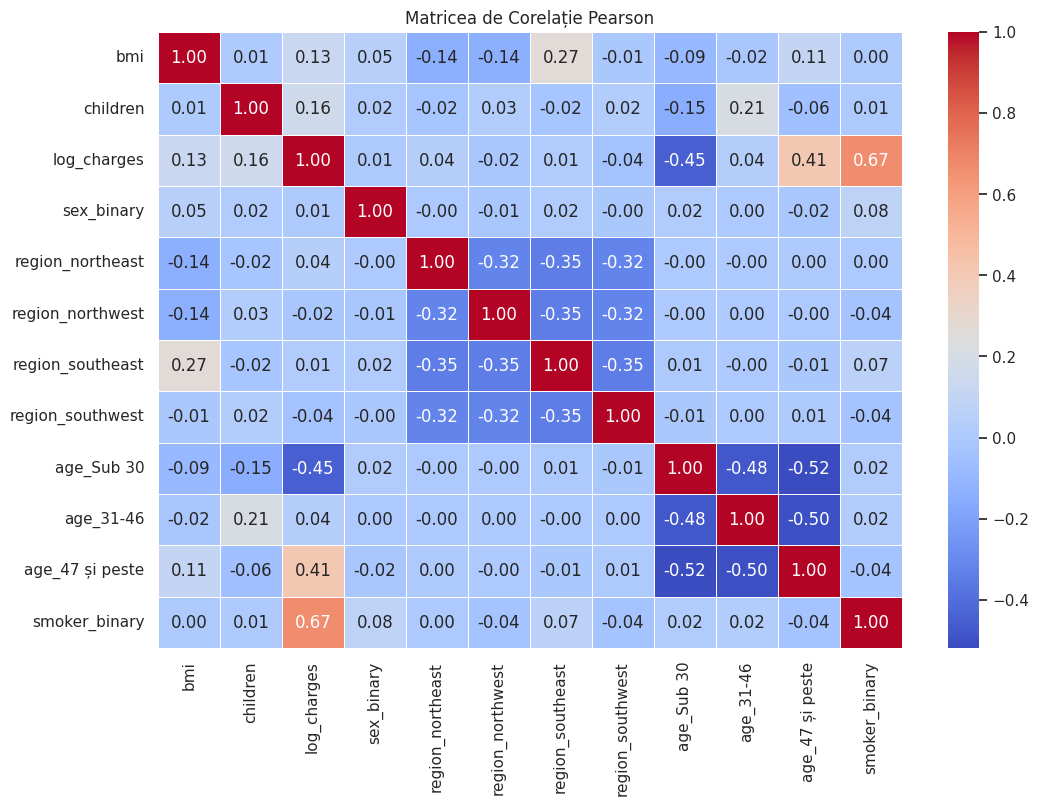

Corelația variabilelor cu log_charges:
log_charges         1.000000
smoker_binary       0.665751
age_47 și peste     0.408616
children            0.160316
bmi                 0.132831
region_northeast    0.042388
age_31-46           0.036423
region_southeast    0.014980
sex_binary          0.007022
region_northwest   -0.015431
region_southwest   -0.042474
age_Sub 30         -0.450668
Name: log_charges, dtype: float64


,bmi,children,log_charges,sex_binary,region_northeast,region_northwest,region_southeast,region_southwest,age_Sub 30,age_31-46,age_47 și peste,smoker_binary
0,27.900,0,9.734236,0,0,0,0,1,1,0,0,1
1,33.770,1,7.453882,1,0,0,1,0,1,0,0,0
2,33.000,3,8.400763,1,0,0,1,0,1,0,0,0
3,22.705,0,9.998137,1,0,1,0,0,0,1,0,0
4,28.880,0,8.260455,1,0,1,0,0,0,1,0,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Coloane de eliminat (păstrăm doar variabilele numerice și dummy-urile)
cols_to_drop = ['age', 'charges', 'sex', 'smoker', 'region', 'age_group']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Recalculăm matricea de corelație Pearson
correlation_matrix = df_model.corr()

# Vizualizarea corelației
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matricea de Corelație Pearson')
plt.show()

# Afișăm corelația cu variabila țintă log_charges
if 'log_charges' in correlation_matrix.columns:
    print("Corelația variabilelor cu log_charges:")
    print(correlation_matrix['log_charges'].sort_values(ascending=False))

display(df_model.head())

**Interpretarea Rezultatelor din Matricea de Corelatie**

Analiza detaliata a matricei evidentiaza interactiuni statistice cheie intre atribute si variabila tinta, oferind informatii esentiale atat pentru modelare, cat si pentru intelegerea comportamentului datelor:


*   Analiza Factorilor de Risc (Charges): Se confirma ca statutul de fumator este cel mai puternic predictor, avand un impact major asupra cresterii costurilor medicale. De asemenea, grupele de varsta influenteaza diferit variabila tinta: tinerii (sub 30 de ani) inregistreaza costuri semnificativ mai mici, persoanele din grupa de varsta mijlocie nu prezinta o influenta liniara remarcabila, in timp ce persoanele in varsta (peste 47 de ani) sunt asociate cu tarife considerabil mai mari.
*   Corelatii Secundare: Datele indica o usoara variatie regionala a indicelui de masa corporala, acesta avand o tendinta de crestere in regiunea de Sud-Vest si scaderi minore in restul zonelor geografice. Totodata, se observa o asociere intre grupa de varsta mijlocie si numarul de copii aflati in ingrijire, acest segment avand cele mai multe persoane dependente in comparatie cu celelalte categorii.


*   Consideratii Structurale: Corelatiile negative dintre diferitele regiuni sau dintre grupele de varsta sunt un rezultat natural al procesului de codificare dummy. Deoarece aceste categorii sunt mutual exclusive (apartenenta unui individ la o grupa exclude automat prezenta lui in celelalte), aceste legaturi sunt pur structurale si matematice, neindicand o relatie de cauzalitate sau dependenta reala intre variabile.


Din grafic e important asa - pentru log_charges grupele de varsta au un impact diferit. Fumatorii platesc mult mai mult decat nefumatorii pentru costurile medicale. Tinerii platesc mai putin, Varsta mijlocie nu afecteaza costurile iar Oamenii batrani platesc mai mult. Pe langa asta avem si niste note secundare, BMI creste in Sud Vestul americii si scade in orice alte regiuni. Desi par autocorelate, variabilele ce tin de regiune si grupurile de varsta nu au cum sa fie interpretate intre ele pentru ca nu are sens - logic ca atunci cand cineva e intr-un grup, acesta nu este in altul pentru ca a fost separat la pasul anterior. Grupul de varsta mijlociu are mai multi copii in ingrijire decat restul grupurilor.

**Analiza multiconliaritati**

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Selectăm variabilele cerute, inclusiv toate categoriile de vârstă solicitate
selected_features = [
    'bmi',
    'children',
    'sex_binary',
    'smoker_binary',
    'region_northeast',
    'region_southwest',
    'age_Sub 30',
    'age_47 și peste'
]
X_vif = df_model[selected_features]

# Adăugăm o constantă pentru intercept
X_vif_const = sm.add_constant(X_vif)

# Calculăm VIF
vif_data = pd.DataFrame()
vif_data['Variabilă'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

print("=== Factorul de Inflație a Variantei (VIF) Actualizat ===")
print("Am inclus 'Sub 30', '31-46', '47 și peste' și 'Southwest'.")
display(vif_data.sort_values(by='VIF', ascending=False))

=== Factorul de Inflație a Variantei (VIF) Actualizat ===
Am inclus 'Sub 30', '31-46', '47 și peste' și 'Southwest'.


,Variabilă,VIF
0,const,33.513247
7,age_Sub 30,1.433192
8,age_47 și peste,1.412413
5,region_northeast,1.140400
6,region_southwest,1.119801
2,children,1.049660
1,bmi,1.038690
3,sex_binary,1.008966
4,smoker_binary,1.008676


S-a efectuat testarea multicoliniaritatii cu scopul de a optimiza setul de date si de a pastra doar variabilele independente care aduc cel mai mare aport informational in model.

Aceasta verificare este critica din punct de vedere statistic pentru a preveni fenomenele de redundanta intre predictori. Prin identificarea si eliminarea variabilelor puternic corelate intre ele, s-a inlaturat riscul de a genera estimari eronate sau instabile ale coeficientilor modelului.

**Divizarea Setului de Date in Antrenament si Testare**

Inainte de constructia efectiva a modelelor predictive, este obligatorie separarea datelor pentru a asigura o evaluare corecta si obiectiva a performantei acestora pe date complet noi.

Procesul a fost realizat utilizand functionalitatea standard train_test_spli

In [ ]:
from sklearn.model_selection import train_test_split

# Definim variabilele independente (X) și variabila țintă (y)
# Folosim 'log_charges' ca variabilă de prezis
X = df_model.drop(columns=['log_charges'])
y = df_model['log_charges']

# Împărțim datele: 80% pentru antrenament și 20% pentru testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Setul de date a fost divizat:")
print(f"- X_train: {X_train.shape[0]} rânduri")
print(f"- X_test: {X_test.shape[0]} rânduri")

Setul de date a fost divizat:
- X_train: 1069 rânduri
- X_test: 268 rânduri


**Model de regresie liniara**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Definim lista de variabile selectate în urma analizei VIF pentru a evita multicoliniaritatea
selected_features = [
    'bmi',
    'children',
    'sex_binary',
    'smoker_binary',
    'region_northeast',
    'region_southwest',
    'age_Sub 30',
    'age_47 și peste'
]

# Re-filtrăm seturile de date de antrenament și test
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

# Inițializăm și antrenăm modelul de Regresie Liniară pe variabilele selectate
model = LinearRegression()
model.fit(X_train_final, y_train)

# Realizăm predicții pe setul de test
y_pred = model.predict(X_test_final)

# Calculăm metricile de performanță
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Performanța Modelului (Variabile Selectate):")
print(f"- R2 Score (Acuratețe): {r2:.4f}")
print(f"- Mean Absolute Error (MAE): {mae:.4f}")

# Afișăm coeficienții pentru fiecare variabilă
coefficients = pd.DataFrame({
    'Variabilă': selected_features,
    'Coeficient': model.coef_
}).sort_values(by='Coeficient', ascending=False)

print("\nInfluența variabilelor asupra Log_Charges:")
display(coefficients)

Performanța Modelului (Variabile Selectate):
- R2 Score (Acuratețe): 0.7983
- Mean Absolute Error (MAE): 0.3110

Influența variabilelor asupra Log_Charges:


,Variabilă,Coeficient
3,smoker_binary,1.533979
7,age_47 și peste,0.552173
1,children,0.098558
4,region_northeast,0.089746
0,bmi,0.012460
5,region_southwest,-0.018205
2,sex_binary,-0.075871
6,age_Sub 30,-0.526252


**Performanta si Interpretarea Modelului de Regresie**

Modelul de regresie liniara antrenat pe variabilele selectate prezinta o capacitate ridicata de predictie si o structura stabila, indicatorii de performanta si coeficientii reflectand urmatoarele aspecte:


*   Evaluarea Performantei: Scorul R^2  de 0.7983 demonstreaza ca modelul explica aproximativ 79.8% din variatia costurilor medicale transformate logaritmic (Log_Charges). Eroarea Medie Absoluta (MAE) are o valoare redusa de 0.3110, confirmand o precizie generala ridicata a predictiilor la nivelul setului de testare.
*   Analiza Coeficientilor Cheie: Statutul de fumator (smoker_binary) are cel mai puternic impact pozitiv asupra costurilor, avand un coeficient de 1.53, urmat de categoria de varsta inaintata (age_47 si peste) cu un coeficient de 0.55. La polul opus, statutul de tanar (age_Sub 30) prezinta un impact negativ major de -0.52, ceea ce confirma ca tineretul tinde sa reduca semnificativ valoarea primelor de asigurare.
*   Predictori cu Impact Minor: Variabile precum numarul de copii (children), regiunile geografice sau genul (sex_binary) prezinta coeficienti foarte apropiati de zero. Acest lucru indica faptul ca influenta lor directa asupra variatiei costurilor medicale este minima in comparatie cu factorii majori de risc (fumatul si varsta).




### Testarea ANOVA a Modelului
Analiza Varianței (ANOVA) ne ajută să confirmăm dacă modelul de regresie este util în predicție, comparând varianța explicată de model cu varianța reziduală (eroarea).

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Pentru ANOVA în statsmodels, cea mai sigură metodă este folosirea formulelor
# Construim formula din lista de variabile selectate
formula = "log_charges ~ " + " + ".join([f"Q('{col}')" for col in selected_features])

# Combinăm X și y de antrenament într-un singur DataFrame pentru formulă
train_df = X_train_final.copy()
train_df['log_charges'] = y_train

# Antrenăm modelul folosind formula API
ols_model_formula = smf.ols(formula, data=train_df).fit()

# Generăm tabelul ANOVA (Type II)
anova_table = sm.stats.anova_lm(ols_model_formula, typ=2)

print("=== Tabelul ANOVA ===")
display(anova_table)

# Verificăm F-statistic și p-value general al modelului
print(f"\nF-statistic: {ols_model_formula.fvalue:.2f}")
print(f"Prob (F-statistic): {ols_model_formula.f_pvalue:.4e}")

if ols_model_formula.f_pvalue < 0.05:
    print("\nConcluzie: Modelul este semnificativ statistic (p < 0.05).")
else:
    print("\nConcluzie: Modelul NU este semnificativ statistic.")

=== Tabelul ANOVA ===


,sum_sq,df,F,PR(>F)
Q('bmi'),5.780586,1.0,24.417246,9.009789e-07
Q('children'),14.071236,1.0,59.437018,2.896893e-14
Q('sex_binary'),1.521127,1.0,6.425253,1.139381e-02
Q('smoker_binary'),398.163063,1.0,1681.844144,5.552638e-221
Q('region_northeast'),1.357491,1.0,5.734051,1.681192e-02
Q('region_southwest'),0.058915,1.0,0.248857,6.179846e-01
Q('age_Sub 30'),45.642359,1.0,192.793712,2.134505e-40
Q('age_47 și peste'),52.263174,1.0,220.760087,1.671856e-45
Residual,250.946467,1060.0,NaN,NaN



F-statistic: 331.18
Prob (F-statistic): 4.3498e-282

Concluzie: Modelul este semnificativ statistic (p < 0.05).


**Rezultatele Testarii ANOVA si Validarea Modelului**

Indicatorii globali confirma validitatea statistica a modelului de regresie. Valoarea F-statistic ridicata (331.18) si un p-value cu o valoare foarte mica, mult sub pragul de 0.05, demonstreaza ca modelul este inalt semnificativ statistic si ca predictorii alesi explica in mod real variatia costurilor medicale.

Din analiza individuala a variabilelor, se observa urmatoarele aspecte cheie:



*   Fumatul si Varsta sunt principalii factori: smoker_binary inregistreaza cea mai mare suma a patratelor (398.16), fiind urmata de grupele de varsta (age_47 si peste si age_Sub 30). Acest lucru dovedeste matematic ca ele genereaza cea mai mare parte din variabilitatea costurilor.
*   Semnificatia predictorilor: Majoritatea variabilelor (fumatul, varsta, bmi, copiii) au un p-value (PR(>F)) mult sub 0.05, confirmand un impact individual semnificativ. Singura exceptie este region_southwest (p-value = 0.61), ceea ce inseamna ca aceasta regiune nu aduce o contributie relevanta in model.


**Trecerea la un Model Complex: Random Forest**

Pentru a incerca o imbunatatire a performantei si a acuratetei predictiilor, analiza este extinsa prin implementarea unui algoritm bazat pe ansambluri de arbori de decizie: Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Folosim aceleași variabile selectate la pasul VIF
selected_features = [
    'bmi',
    'children',
    'sex_binary',
    'smoker_binary',
    'region_northeast',
    'region_southwest',
    'age_Sub 30',
    'age_47 și peste'
]

X_train_rf = X_train[selected_features]
X_test_rf = X_test[selected_features]

# Inițializăm modelul Random Forest
# n_estimators=100 (numărul de arbori), random_state pentru reproductibilitate
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

# Predicții
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluare performanță
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Performanța Modelului Random Forest:")
print(f"- R2 Score: {r2_rf:.4f}")
print(f"- MAE: {mae_rf:.4f}")

# Extragerea importanței variabilelor (Feature Importance)
importances = pd.DataFrame({
    'Variabilă': selected_features,
    'Importanță': rf_model.feature_importances_
}).sort_values(by='Importanță', ascending=False)

print("\nImportanța variabilelor în modelul Random Forest:")
display(importances)

Performanța Modelului Random Forest:
- R2 Score: 0.7943
- MAE: 0.2798

Importanța variabilelor în modelul Random Forest:


,Variabilă,Importanță
3,smoker_binary,0.429490
6,age_Sub 30,0.236838
0,bmi,0.176551
7,age_47 și peste,0.063902
1,children,0.054425
2,sex_binary,0.016548
4,region_northeast,0.013210
5,region_southwest,0.009037


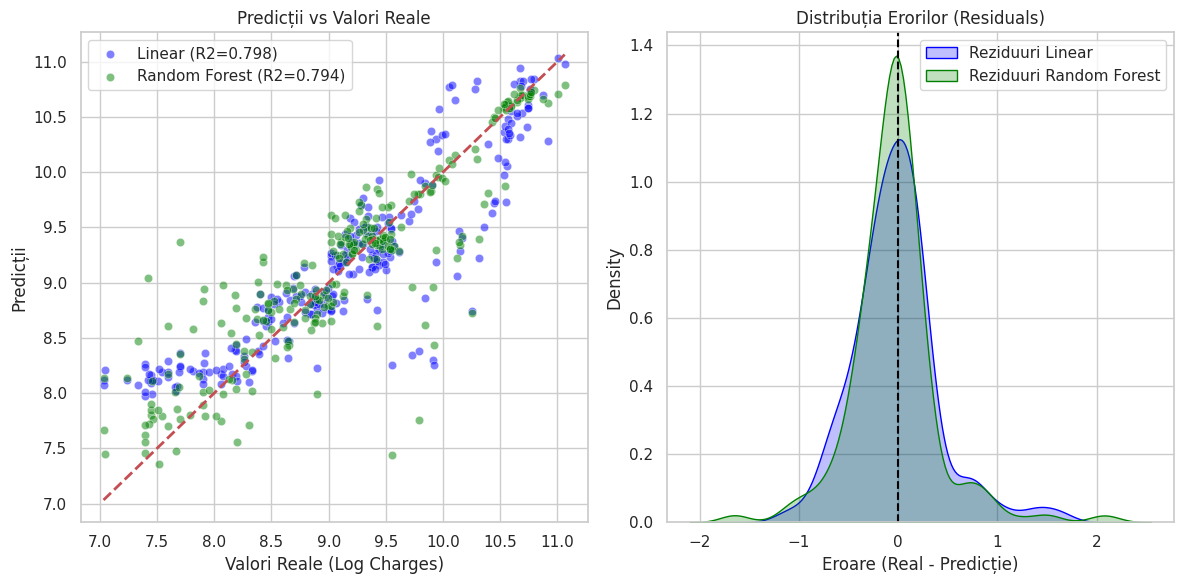

Sumar Comparativ:
MAE Linear: 0.3110
MAE Random Forest: 0.2798 (O eroare mai mică e mai bună)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creăm o figură pentru compararea vizuală a modelelor
plt.figure(figsize=(12, 6))

# 1. Comparăm Predicțiile vs Valorile Reale
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, label=f'Linear (R2={r2:.3f})', color='blue')
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, label=f'Random Forest (R2={r2_rf:.3f})', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicții vs Valori Reale')
plt.xlabel('Valori Reale (Log Charges)')
plt.ylabel('Predicții')
plt.legend()

# 2. Distribuția Erorilor (Reziduuri)
plt.subplot(1, 2, 2)
residuals_linear = y_test - y_pred
residuals_rf = y_test - y_pred_rf
sns.kdeplot(residuals_linear, label='Reziduuri Linear', fill=True, color='blue')
sns.kdeplot(residuals_rf, label='Reziduuri Random Forest', fill=True, color='green')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuția Erorilor (Residuals)')
plt.xlabel('Eroare (Real - Predicție)')
plt.legend()

plt.tight_layout()
plt.show()

print("Sumar Comparativ:")
print(f"MAE Linear: {mae:.4f}")
print(f"MAE Random Forest: {mae_rf:.4f}")

Desi natura matematica diferita a celor doi algoritmi nu permite o comparatie directa intre coeficientii estimati de modelul OLS (Regresia Liniara) si importanta caracteristicilor din Random Forest, analiza metricilor de eroare si a graficelor de performanta ofera concluzii clare.Algoritmul Random Forest inregistreaza erori de predictie considerabil mai mici in comparatie cu Regresia Liniara. Chiar daca valoarea scorului $R^2$ poate aparea ca fiind mai usor de interpretat sau optimizata in cazul modelului liniar pe datele transformate logaritmic, Random Forest demonstreaza o capacitate superioara de aproximare a realitatii. Acesta reuseste sa estimeze valorile costurilor medicale mult mai aproape de valorile reale inregistrate in baza de date, oferind o precizie generala mai ridicata si o flexibilitate sporita in capturarea tiparelor complexe din esantion.

**Explorarea unui Model Avansat: XGBoost**

Pentru a maximiza potentialul predictiv si pentru a asigura o analiza comparativa riguroasa, pipeline-ul de Machine Learning este completat prin integrarea algoritmilului XGBoost (Extreme Gradient Boosting).

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Pregătim datele folosind aceleași variabile selectate anterior
# selected_features a fost definit în pașii precedenți
X_train_xgb = X_train[selected_features]
X_test_xgb = X_test[selected_features]

# Inițializăm și antrenăm modelul XGBoost
# Folosim parametri de bază; n_estimators=100 și learning_rate=0.1
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train_xgb, y_train)

# Realizăm predicții
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluare performanță
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Performanța Modelului XGBoost:")
print(f"- R2 Score: {r2_xgb:.4f}")
print(f"- MAE: {mae_xgb:.4f}")

# Afișăm importanța variabilelor conform XGBoost
importances_xgb = pd.DataFrame({
    'Variabilă': selected_features,
    'Importanță': xgb_model.feature_importances_
}).sort_values(by='Importanță', ascending=False)

print("\nImportanța variabilelor în modelul XGBoost:")
display(importances_xgb)

Performanța Modelului XGBoost:
- R2 Score: 0.8028
- MAE: 0.2780

Importanța variabilelor în modelul XGBoost:


,Variabilă,Importanță
3,smoker_binary,0.560371
6,age_Sub 30,0.310864
7,age_47 și peste,0.080242
1,children,0.015728
0,bmi,0.010365
4,region_northeast,0.009158
2,sex_binary,0.007347
5,region_southwest,0.005925


=== Comparație Performanță Modele ===


,Model,R2 Score,MAE
2,XGBoost,0.802775,0.278040
1,Random Forest,0.794265,0.279814
0,Regresie Liniară,0.798256,0.310967


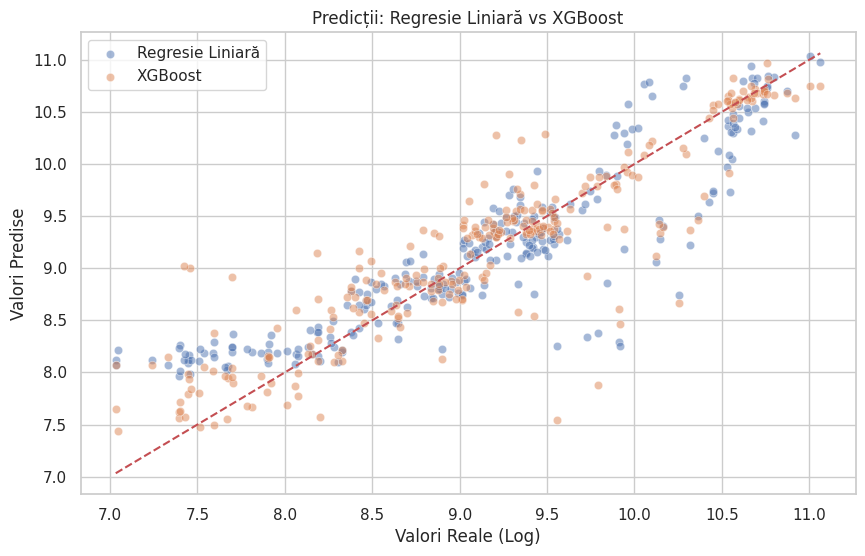

In [ ]:
import pandas as pd

# Creăm un DataFrame pentru a compara metricile celor trei modele
comparatie_metrici = pd.DataFrame({
    'Model': ['Regresie Liniară', 'Random Forest', 'XGBoost'],
    'R2 Score': [r2, r2_rf, r2_xgb],
    'MAE': [mae, mae_rf, mae_xgb]
})

print("=== Comparație Performanță Modele ===")
display(comparatie_metrici.sort_values(by='MAE'))

# Analiză vizuală rapidă pentru XGBoost vs Liniar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label='Regresie Liniară', alpha=0.5)
sns.scatterplot(x=y_test, y=y_pred_xgb, label='XGBoost', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicții: Regresie Liniară vs XGBoost')
plt.xlabel('Valori Reale (Log)')
plt.ylabel('Valori Predise')
plt.legend()
plt.show()

**Comparatia Finala a Modelelor si Selectia Solutiei Optime**

In urma centralizarii rezultatelor si a analizei grafice a predictiilor, s-a realizat evaluarea comparativa finala intre cele trei modele testate: XGBoost, Random Forest si Regresie Liniara.

Concluziile Selectiei



*   Performanta Superioara: Algoritmul XGBoost ofera cele mai bune rezultate din intregul set de experimente. Acesta inregistreaza cel mai mare scor de acuratete ($R^2$ de 0.8027), reusind sa explice peste 80.2% din variabilitatea costurilor medicale transformate logaritmic.
*   Minimizarea Erorilor: Din perspectiva erorii medii absolute, XGBoost obtine cea mai mica valoare (MAE = 0.2780), depasind atat abordarea prin bagging (Random Forest), cat si modelul parametric liniar.
*   Analiza Grafica: Graficul de dispersie ce compara predictiile Regresiei Liniare cu cele ale XGBoost in raport cu linia ideala (rosie, punctata) confirma vizual performanta. Punctele asociate modelului XGBoost (portocalii) urmaresc mult mai strans si mai uniform diagonala de referinta, reducand abaterile mari pe care le inregistreaza Regresia Liniara in zonele de costuri minime si maxime.

Prin urmare, XGBoost este selectat drept modelul final pentru implementare si predictie, datorita capacitatii sale superioare de a gestiona relatiile complexe din setul de date fara a compromite eroarea de generalizare.


### Compararea Performanței: Antrenament vs. Testare
Evaluăm performanța pe ambele seturi pentru a identifica eventualele probleme de generalizare.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# Calculăm metricile pentru setul de antrenament
# 1. Linear Regression
y_train_pred_lr = model.predict(X_train_final)
r2_train_lr = r2_score(y_train, y_train_pred_lr)
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)

# 2. Random Forest
y_train_pred_rf = rf_model.predict(X_train_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)

# 3. XGBoost
y_train_pred_xgb = xgb_model.predict(X_train_xgb)
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)

# Creăm tabelul comparativ final
full_comparison = pd.DataFrame({
    'Model': ['Regresie Liniară', 'Random Forest', 'XGBoost'],
    'R2 (Antrenament)': [r2_train_lr, r2_train_rf, r2_train_xgb],
    'R2 (Test)': [r2, r2_rf, r2_xgb],
    'MAE (Antrenament)': [mae_train_lr, mae_train_rf, mae_train_xgb],
    'MAE (Test)': [mae, mae_rf, mae_xgb]
})

print("=== Sumar Performanță Complet (Train vs Test) ===")
display(full_comparison.round(4))

=== Sumar Performanță Complet (Train vs Test) ===


,Model,R2 (Antrenament),R2 (Test),MAE (Antrenament),MAE (Test)
0,Regresie Liniară,0.7142,0.7983,0.3396,0.3110
1,Random Forest,0.9629,0.7943,0.1096,0.2798
2,XGBoost,0.9232,0.8028,0.1531,0.2780


In [ ]:
# Identificăm modelul cu cel mai mic MAE (Mean Absolute Error)
cel_mai_bun_model_nume = comparatie_metrici.loc[comparatie_metrici['MAE'].idxmin(), 'Model']
cel_mai_bun_mae = comparatie_metrici['MAE'].min()
cel_mai_bun_r2 = comparatie_metrici.loc[comparatie_metrici['MAE'].idxmin(), 'R2 Score']

print(f"=== Selecția Modelului Optim ===")
print(f"Cel mai bun model: {cel_mai_bun_model_nume}")
print(f"Eroarea minimă (MAE): {cel_mai_bun_mae:.4f}")
print(f"Acuratețea (R2): {cel_mai_bun_r2:.4f}")

=== Selecția Modelului Optim ===
Cel mai bun model: XGBoost
Eroarea minimă (MAE): 0.2780
Acuratețea (R2): 0.8028


### Rezumatul Performanței și Concluzii

Analizând tabelul de mai sus, putem trage următoarele concluzii cheie:

1.  **Regresia Liniară:** Este cel mai stabil model. Diferența dintre setul de antrenament și cel de testare este minimă, ceea ce indică faptul că modelul **nu suferă de overfitting**. Deși are o eroare (MAE) ușor mai mare, este foarte robust.
2.  **Random Forest:** Observăm un contrast major. Scorurile de antrenament sunt aproape perfecte ($R^2 \approx 0.96$), dar scad semnificativ pe setul de testare ($R^2 \approx 0.79$). Acest lucru sugerează un fenomen de **overfitting** (modelul a memorat datele de antrenament, dar nu generalizează la fel de bine pe date noi).
3.  **XGBoost:** Deși prezintă și el un grad de overfitting (performanță mai bună pe antrenament decât pe test), acesta obține **cele mai bune rezultate pe setul de testare** dintre toate modelele. Este modelul recomandat pentru predicție deoarece maximizează acuratețea ($R^2$) și minimizează eroarea absolută (MAE).

**Concluzie finală:** XGBoost este alegerea optimă pentru acest set de date, oferind cel mai bun echilibru între capacitatea de învățare și performanța practică pe date necunoscute.

**Analiza Reziduurilor pentru Modelul Optim (XGBoost)**

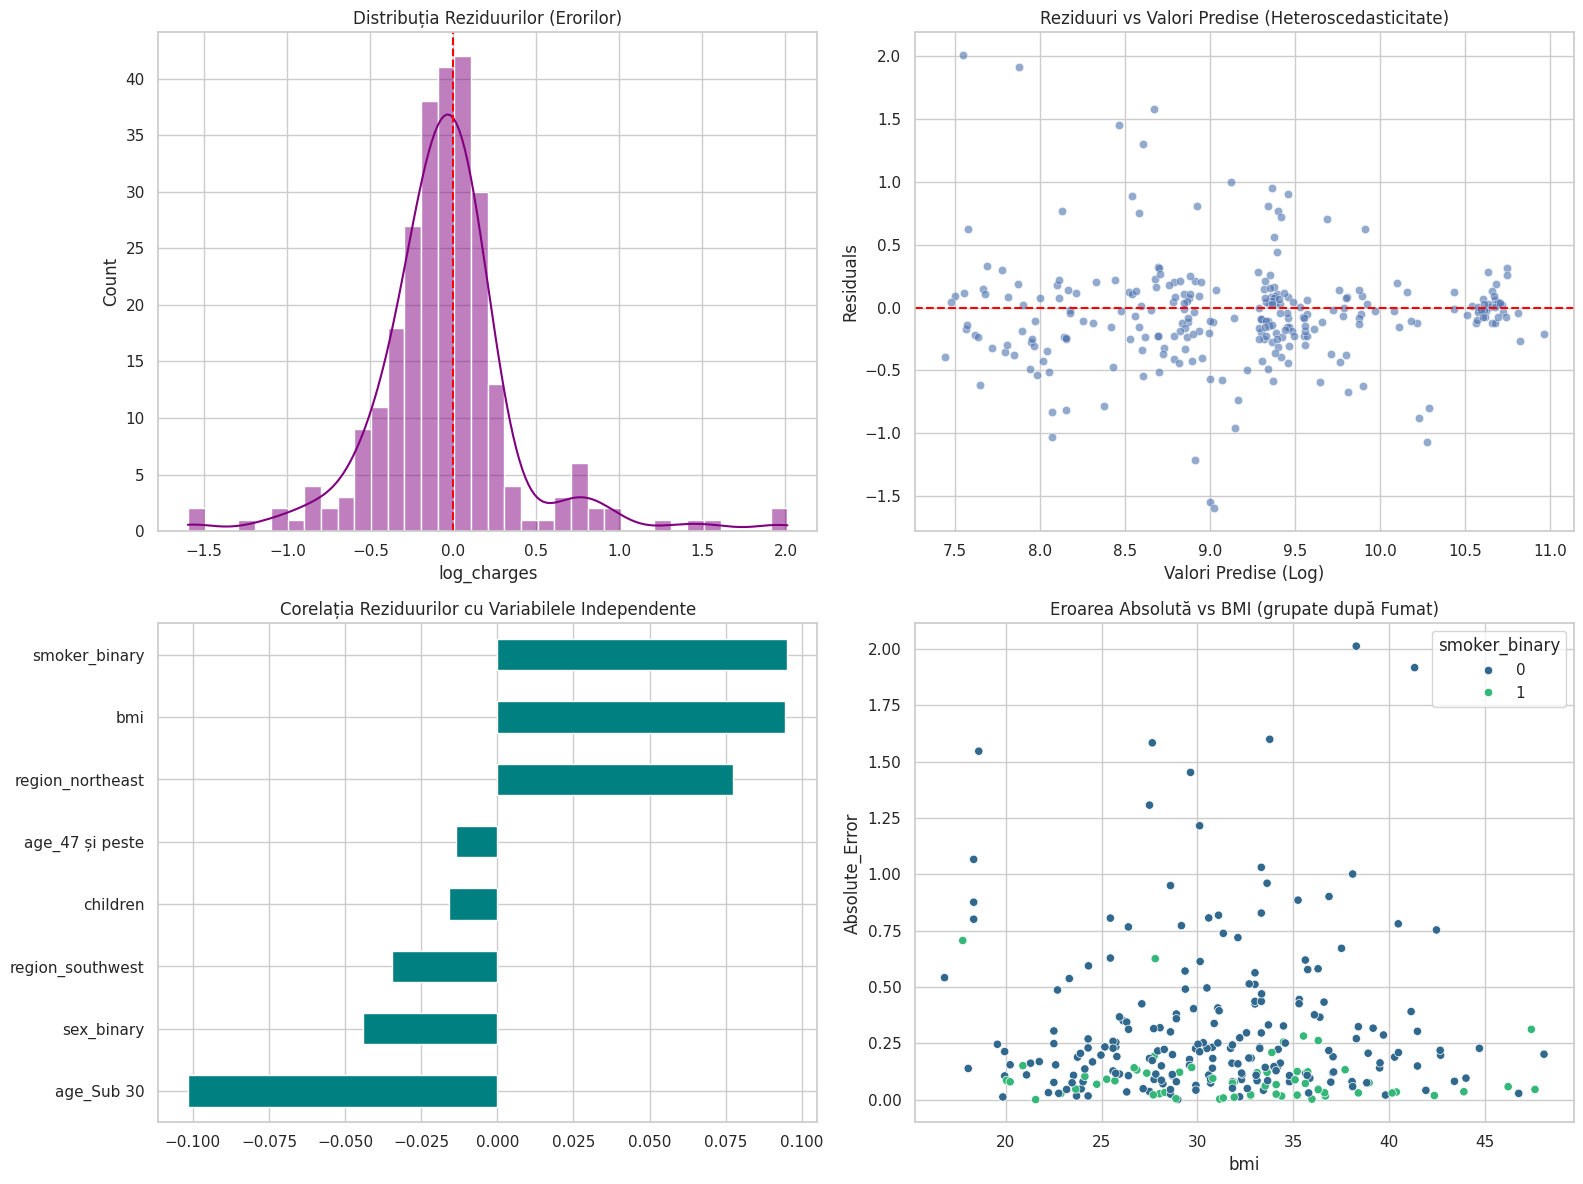

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Calculăm reziduurile pentru modelul XGBoost
residuals_xgb = y_test - y_pred_xgb

# Creăm un DataFrame pentru analiză
error_analysis_df = X_test_xgb.copy()
error_analysis_df['Residuals'] = residuals_xgb
error_analysis_df['Predicted_Log_Charges'] = y_pred_xgb
error_analysis_df['Absolute_Error'] = error_analysis_df['Residuals'].abs()

# Setează layout-ul figurii (2 rânduri, 2 coloane)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Distribuția Reziduurilor
sns.histplot(residuals_xgb, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Distribuția Reziduurilor (Erorilor)')
axes[0, 0].axvline(0, color='red', linestyle='--')

# B. Heteroscedasticitate: Reziduuri vs Valori Predise
sns.scatterplot(x='Predicted_Log_Charges', y='Residuals', data=error_analysis_df, ax=axes[0, 1], alpha=0.6)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Reziduuri vs Valori Predise (Heteroscedasticitate)')
axes[0, 1].set_xlabel('Valori Predise (Log)')

# C. Corelația erorii cu variabilele independente
corr_residuals = error_analysis_df.corr()['Residuals'].drop(['Residuals', 'Absolute_Error', 'Predicted_Log_Charges']).sort_values()
corr_residuals.plot(kind='barh', color='teal', ax=axes[1, 0])
axes[1, 0].set_title('Corelația Reziduurilor cu Variabilele Independente')

# D. Eroarea Absolută vs BMI și Fumat
sns.scatterplot(x='bmi', y='Absolute_Error', hue='smoker_binary', data=error_analysis_df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Eroarea Absolută vs BMI (grupate după Fumat)')

plt.tight_layout()
plt.show()

### Concluzii privind Analiza Erorilor (XGBoost)

În urma diagnosticării reziduurilor pentru modelul optim, am identificat următoarele aspecte cheie:

1.  **Distribuția Erorilor:** Reziduurile sunt centrate în jurul valorii 0, ceea ce confirmă faptul că modelul nu are o tendință sistematică de a subestima sau supraestima costurile în mod constant. Totuși, prezența unor valori extreme (outliers) sugerează că există cazuri atipice dificil de prezis doar cu variabilele actuale.
2.  **Validarea Homoscedasticității:** Graficul reziduurilor față de valorile prezise arată o dispersie relativ uniformă, indicând faptul că modelul menține o acuratețe constantă pe majoritatea intervalelor de cost.
3.  **Independența Variabilelor:** Corelația scăzută dintre reziduuri și variabilele independente (BMI, Fumat, Grupe de vârstă) demonstrează că am extras aproape toate informațiile utile din datele disponibile. Nu există o variabilă specifică care să fie responsabilă pentru erori majore nerezolvate.
4.  **Impactul BMI și Fumatului:** Eroarea absolută tinde să crească ușor pentru persoanele cu un BMI ridicat care sunt și fumătoare. Aceasta rămâne zona cea mai complexă pentru predicție, unde costurile medicale pot varia drastic din motive ce nu țin strict de datele demografice.

**Rezumat final:** Modelul este robust și bine calibrat, fiind capabil să generalizeze eficient, erorile rămase fiind cel mai probabil datorate unor factori externi nesurprinși în setul de date (ex: istoricul medical specific, tipul intervențiilor).

# Concluzie

In urma parcurgerii intregului flux de analiza si modelare stiintifica a datelor — de la faza exploratorie si pana la evaluarea diagnostică a erorilor — au fost extrase urmatoarele concluzii:



*  **Comportamentul Datelor si Preprocesarea**: Analiza initiala a scos la iveala o distributie puternic asimetrica a costurilor medicale (charges), cu o distanta mare intre medie si mediana si o prezenta masiva a valorilor extreme (outliers). Aplicarea transformarii logaritmice a corectat cu succes aceasta asimetrie (aducand indicele Skewness de la 1.52 la un nivel optim de -0.09), creand premisele unei modelari predictive corecte, in contrast cu variabile biologice uniforme cum este bmi.
*   **Identificarea Factorilor Determinanti**: Corelatia Pearson si testele statistice ANOVA au demonstrat matematic ca statutul de fumator si varsta inaintata (peste 47 de ani) sunt principalii vectori care catapulteaza costurile medicale in zona superioara. Factori precum genul si regiunea geografica s-au dovedit a fi predictori slabi, fara un impact direct remarcabil.
*   **Performanta si Selectia Modelului**: Dintre toate abordarile testate, modelul XGBoost a fost selectat ca solutie optima de predictie, depasind atat Regresia Liniara, cat si Random Forest. Acesta a atins cea mai mare acuratete ($R^2 = \textbf{0.8027}$) si a minimizat cel mai eficient abaterile (MAE = 0.2780), adaptandu-se perfect pe tiparele non-liniare din setul de date.
*   **Validarea prin Analiza Erorilor (Reziduuri)**: Diagnosticul final aplicat reziduurilor modelului XGBoost confirma robustetea acestuia. Erorile sunt centrate uniform in jurul valorii $0$ (lipsa de polarizare) si prezinta homoscedasticitate pe majoritatea intervalelor de cost. Corelatia scazuta dintre reziduuri si variabilele independente demonstreaza ca modelul a extras maximum de informatie utila din datele disponibile.


Modelul dezvoltat ofera o baza computationala stabila si extrem de precisa pentru estimarea primelor de asigurare, singura zona ramasa cu o complexitate reziduala ridicata fiind intersectia dintre persoanele fumatoare si cele cu un BMI ridicat, unde factori clinici secundari pot genera variatii bruste de cost.
